<a href="https://colab.research.google.com/github/abinayanand7896-cloud/Abinaya_Anand/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Importing libraries:**

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

**2. Dataset Loading**

In [54]:
df=pd.read_csv('/content/Telco-Customer-Churn.csv')

#Splitting the Dataset into training and testing

df_train, df_test = sklearn.model_selection.train_test_split(df, test_size=0.2, random_state=42,stratify=df['Churn'])

print("Shape before splitting:", df.shape)
print("df_train:", df_train.shape)
print("df_test:", df_test.shape)

Shape before splitting: (7043, 21)
df_train: (5634, 21)
df_test: (1409, 21)


**3. Data Exploration:**

**3.1. Displaying the sample data and Null Checks:**

In [55]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 
 1

In [56]:
print(df_train.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**3.2. Analyzing the categorical and numerical features:**

**Tenure:**

This feature has an information about the number of months customers are there with the company. This will give us a good insight on the customer's behaviour and retention.

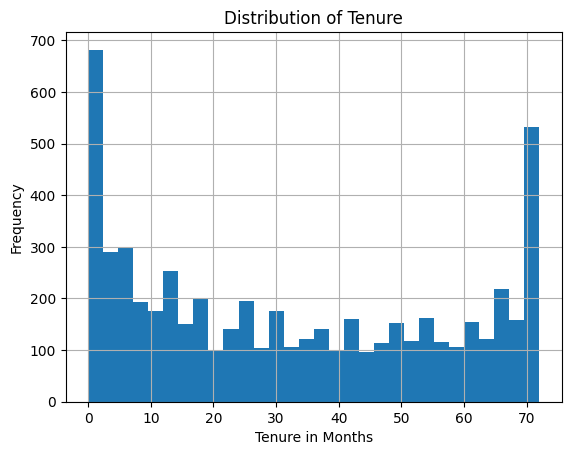

In [57]:
df_train['tenure'].hist(bins=30)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure in Months')
plt.ylabel('Frequency')
plt.show()

**Monthly charges:**

This feature represents how much the customer has a monthly charges. The below histogram represents how does the monthly charges are distributed to teh customers.

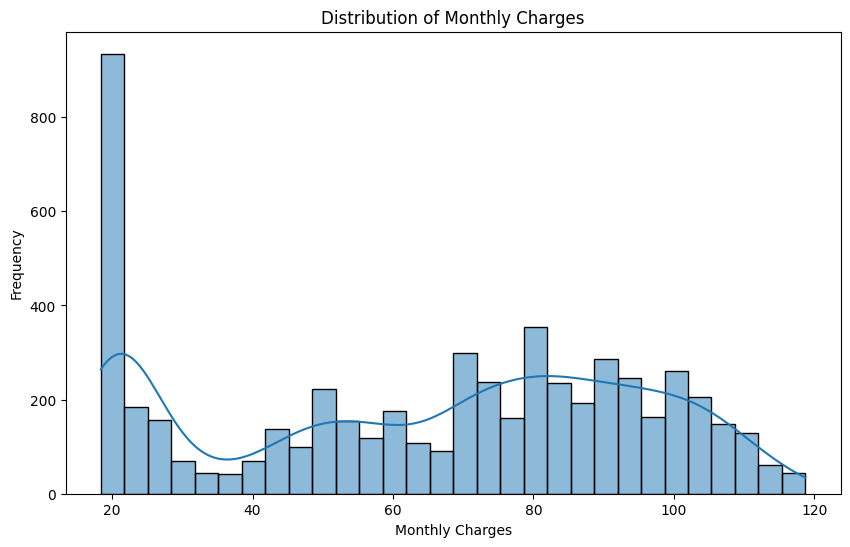

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(df_train['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

**SeniorCitizen:**

This feature has a value of 0 and 1. O represents that the customer is non-senior citizen whereas 1 is senior citizens. Though the value is represented in numeric, it is a categorical variables as it contains only two unique values.

Text(0, 0.5, 'Count')

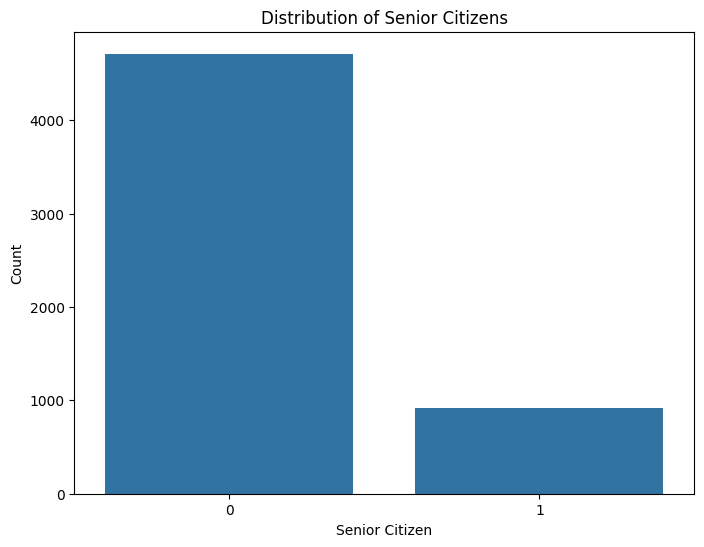

In [59]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='SeniorCitizen')
plt.title('Distribution of Senior Citizens')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')

**3.3. Analysing the churn with contract type:**

I have used the bar chart to visualize the customer churn by contract in each category which is month-to-month, one year and two year contacts.

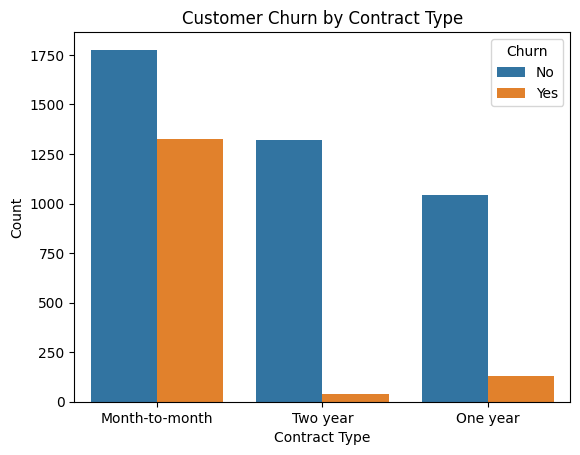

In [60]:
sns.countplot(data=df_train, x='Contract', hue='Churn')
plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

By looking at this result, we could see that month-to-month contracts churn rate are so high whereas one and two years contract has less.

**3.4. Target Variable(churn) Distribution:**

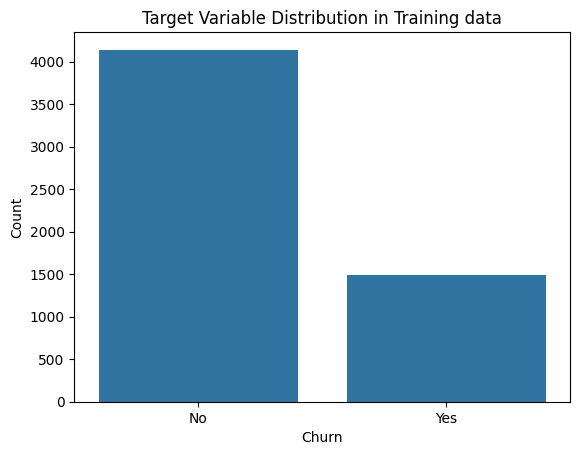

In [61]:
sns.countplot(data=df_train, x='Churn')
plt.title('Target Variable Distribution in Training data')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

**4. Data Preprocessing:**

In [62]:
#data type conversion

df_train['TotalCharges'] = pd.to_numeric(df_train['TotalCharges'], errors='coerce')
df_test['TotalCharges'] = pd.to_numeric(df_test['TotalCharges'],errors='coerce')

In [63]:
#handling null values

df_train['TotalCharges'].fillna(df_train['TotalCharges'].mean(), inplace=True)
df_test['TotalCharges'].fillna(df_test['TotalCharges'].mean(), inplace=True)

In [64]:
#dropping unnecessary columns

df_train.drop('customerID', axis=1, inplace=True)
df_test.drop('customerID', axis=1, inplace=True)

In [65]:
#check shape of the dataset after dropping column

print("Train data shape:", df_train.shape)
print("Test data shape:", df_test.shape)

Train data shape: (5634, 20)
Test data shape: (1409, 20)


In [66]:
#encoding categorical variables

df_train= pd.get_dummies(df_train,columns=['Partner', 'Dependents', 'PhoneService', 'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','gender', 'Contract', 'PaymentMethod', 'InternetService'], drop_first=True)
df_test = pd.get_dummies(df_test,columns=['Partner', 'Dependents', 'PhoneService', 'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','gender', 'Contract', 'PaymentMethod', 'InternetService'], drop_first=True)

In [67]:
#Splitfeatures and target label

x_train=df_train.drop("Churn", axis=1)
y_train=df_train["Churn"]
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

x_test=df_test.drop("Churn", axis=1)
y_test=df_test["Churn"]
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (5634, 30)
y_train: (5634,)
x_test: (1409, 30)
y_test: (1409,)


In [68]:
#scaling numerical features

scaler = StandardScaler()
x_train[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(x_train[['tenure', 'MonthlyCharges', 'TotalCharges']])
x_test[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(x_test[['tenure', 'MonthlyCharges', 'TotalCharges']])

**5. Feature Engineering**

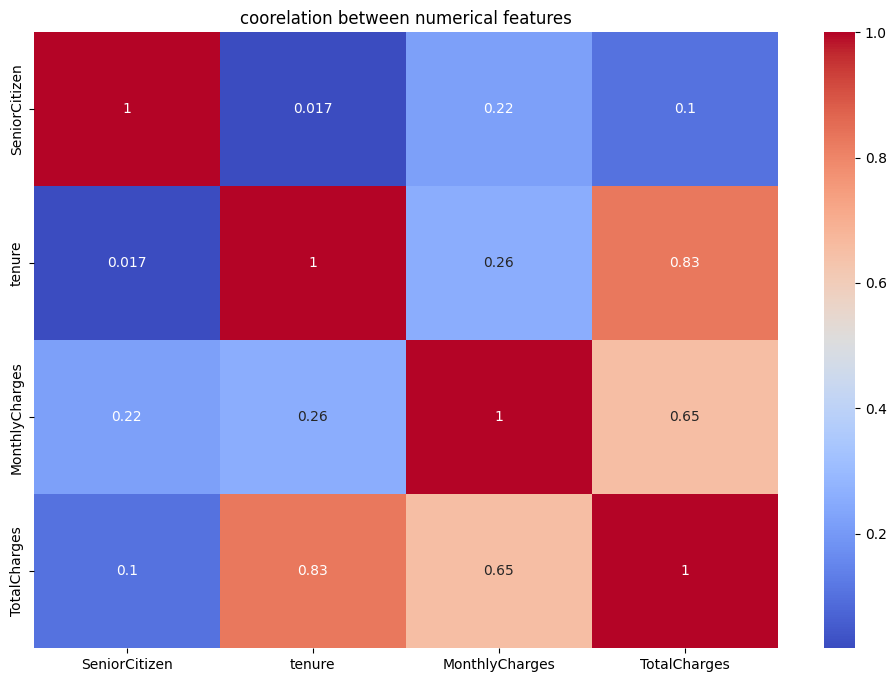

In [69]:
coor=x_train.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12,8))
sns.heatmap(coor, annot=True, cmap='coolwarm')
plt.title('coorelation between numerical features')
plt.show()

In [70]:
#Encoding target variable

y_train = y_train.apply(lambda x:1 if x=="Yes" else 0)
y_test = y_test.apply(lambda x:1 if x=="Yes" else 0)



In [71]:
y_train.value_counts()

,count
Churn,
0,4139
1,1495


**6. Model Training**

In [72]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [73]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [74]:
# Random Forest (baseline)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [75]:
#Making predictions on the test set
y_pred_log_reg = log_reg.predict(x_test)
y_pred_dt = dt_model.predict(x_test)
y_pred_rf = rf_model.predict(x_test)

**Hyperparameter tuning with grid search**

In [76]:
param_grid_log_reg = {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10],'solver': ['lbfgs']}

grid_log_reg = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_log_reg,cv=3,scoring='roc_auc',n_jobs=-1,verbose=2)

grid_log_reg.fit(x_train, y_train)

print("Best Logistic Regression Params:", grid_log_reg.best_params_)
best_log_reg = grid_log_reg.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Logistic Regression Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [77]:
param_grid_dt = {'criterion': ['gini', 'entropy'],'max_depth': [None, 5, 10, 20],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid_dt,cv=3,scoring='roc_auc',n_jobs=-1,verbose=2)

grid_dt.fit(x_train, y_train)

print("Best Decision Tree Params:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [78]:
param_grid_rf = {'n_estimators': [100, 200, 300],'max_depth': [None, 10, 20],'min_samples_split': [2, 5],'min_samples_leaf': [1, 2],'max_features': ['sqrt', 'log2']}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),param_grid_rf,cv=5,scoring='roc_auc',n_jobs=-1,verbose=2)

grid_rf.fit(x_train, y_train)

print("Best Random Forest Params:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Random Forest Params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


**7. Model Evaluation**

In [79]:
print("Logistic Regression Results")

y_pred_log_reg = best_log_reg.predict(x_test)
report_log_reg = classification_report(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, best_log_reg.predict_proba(x_test)[:,1])

print("Classification Report:\n", report_log_reg)
print("ROC-AUC:", roc_auc_log_reg)

Logistic Regression Results
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC: 0.8409982174688057


In [80]:
print("Decision Tree Results")

y_pred_dt = best_dt.predict(x_test)
report_dt = classification_report(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, best_dt.predict_proba(x_test)[:,1])

print("Classification Report:\n", report_dt)
print("ROC-AUC:", roc_auc_dt)

Decision Tree Results
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8281123252990261


In [81]:
print("Random forest Results")

y_pred_rf = best_rf.predict(x_test)
report_rf = classification_report(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, best_rf.predict_proba(x_test)[:,1])

print("Classification Report:\n", report_rf)
print("ROC-AUC:", roc_auc_rf)

Random forest Results
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8423118654576456
